## Flat field correction using BaSiC

This notebook is an implementation of [BaSiCPy](https://basicpy.readthedocs.io/en/latest/installation.html) to perform flat field correction on a series of multi-channel maximum intensity projections (MIPs). 

The notebook will read in in MIPs from a given folder to memory, extract the name of each file and group them for flat field correction using groups defined in a metadata CSV file (by default, "experimental-groups.csv"). Channels are separated, grouped by experimental group for correction and, subsequently, FF-corrected multi-channel MIPs are rebuilt and written to disk 

In [1]:
# Import necessary packages

import re
import glob
import sys, os
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
import logging

import tifffile as tiff
from tifffile import imread, imwrite
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from skimage import feature, io
from scipy.stats import norm
from scipy.ndimage import label, find_objects

# Make path for scripts relative to the working directory
sys.path.insert(0, '../src')  # Adjust the path as needed

# Setup basic logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Silence JAX-related warnings in non-GPU machines
import os
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["BASIC_LOG_LEVEL"] = "WARNING"

In [2]:
# Import BaSiCPy to do flatfield correction  

import importlib
util = importlib.import_module("jax._src.numpy.util")
if not hasattr(util, "_wraps") and hasattr(util, "implements"):
    setattr(util, "_wraps", getattr(util, "implements"))
    print("Patched: jax._src.numpy.util._wraps -> implements")

from basicpy import BaSiC

Patched: jax._src.numpy.util._wraps -> implements


In [3]:
# Define path names and data folders to process

# Define the location of the files to read
parent_directory = "/Users/nestor/Documents/NYU-ISG/microscope-data" # data directory containing your experiments
repo_directory = "/Users/nestor/Documents/NYU-ISG/python_image-analysis" # analysis code directory where results and code are stored

# List the experiments to process -- the folder names that are in parent_directory
experiment_list = ["10012025_hCEC_gH2AX-EdU", "10062025_hCEC_gH2AX-EdU"]

In [4]:
# Do some housekeeping first

# Define the folder structure within each experiment --
# modify this if different in your experiment
# "image" and "mask_n" point to the subdirectories within each experiment that contain the MIPs and nuclear masks
file_folders = {
    "image": "MIPs/MIPs_multichannel/", 
    "mask_n": "segmentation-masks/nuclei_masks/"
}

# Load the function img_loadr() 
from load_files import img_loadr

def extract_base_name(filename):
    """
    Extract the base name from the file name without removing important parts of the name,
    such as the date and experiment information, while stripping the channel prefixes from masks.
    """
    name = os.path.basename(filename)

    # Only remove 'C1-', 'C2-', etc., from mask files
    if name.startswith(("C1-", "C2-", "C3-", "C4-", "C5-")):
        name = name[3:]  # Remove the first 3 characters (e.g., 'C1-', 'C2-', etc)
    
    # Remove the "_cp_masks" suffix for masks or ".ome" from image files if present
    name = name.replace("_cp_masks", "").replace(".ome", "")
    
    # Remove the file extension
    base_name = os.path.splitext(name)[0]
    
    return base_name

In [5]:
# CHUNK 1 # 
# Load maximum intensity projection (MIP) files
# and segmentation masks for images in all experiments listed

# Create a dictionary to store data across multiple experiments
all_experiments_data = {}

# Iterate through each experiment in experiment_list
for experiment in experiment_list:
    # Initialize data structures for the current experiment
    exp_data = {
        "all_images": {"image": [], "mask_n": []},
        "file_names": {"image": [], "mask_n": []},
        "base_names": {"image": [], "mask_n": []},
        "errors": []
    }

    # Read in the experimental groups reference file for each experiment
    exp_groups = pd.read_csv(os.path.join(parent_directory, experiment, "experimental-groups.csv"))

    # Process each file type using img_loadr
    with ThreadPoolExecutor(max_workers=4) as executor:
        for f in file_folders:
            file_path = os.path.join(parent_directory, experiment, file_folders[f])
            files = glob.glob(os.path.join(file_path, "*.tif"))
            results = executor.map(img_loadr, files)

            for result in results:
                image, filename = result
                if image is not None:
                    exp_data["all_images"][f].append(image)
                    exp_data["file_names"][f].append(filename)
                    exp_data["base_names"][f].append(extract_base_name(filename))
                else:
                    exp_data["errors"].append(f"Error loading {filename}")

    # Log the completion of processing for this experiment
    if exp_data["errors"]:
        logging.error(f"{experiment}: Completed with errors in {len(exp_data['errors'])} files.")
    else:
        logging.info(f"{experiment}: All images and masks processed successfully without errors.")
    
    # Store the experiment's data under its name
    all_experiments_data[experiment] = exp_data

# Optional: Summary of processed files for all experiments
for experiment, data in all_experiments_data.items():
    logging.info(f"{experiment}: Processed {len(data['file_names']['image'])} images and {len(data['file_names']['mask_n'])} nuclei masks.")
    
# Now for each experiment, all_images["image"] contains all the images (MIPs), 
# all_images["mask_n"] contains all the nuclei masks and 

2025-10-17 17:06:20,268 - INFO - 10012025_hCEC_gH2AX-EdU: All images and masks processed successfully without errors.
2025-10-17 17:06:23,554 - INFO - 10062025_hCEC_gH2AX-EdU: All images and masks processed successfully without errors.
2025-10-17 17:06:23,559 - INFO - 10012025_hCEC_gH2AX-EdU: Processed 100 images and 100 nuclei masks.
2025-10-17 17:06:23,560 - INFO - 10062025_hCEC_gH2AX-EdU: Processed 150 images and 150 nuclei masks.


In [6]:
# Optional: check dimensions of a given set of images, to verify they're correct

# Define function to check dimensions of images and masks
def img_sizr(image_types, file_indices, all_images):
    for f in file_indices:
        for image_type in image_types:
            try:
                image_shape = all_images[image_type][f].shape
                logging.info(f"File {f} ({image_type}): {image_shape}")
            except IndexError:
                logging.warning(f"File index {f} for {image_type} is out of range.")
            except KeyError:
                logging.error(f"Image type {image_type} does not exist.")

# Define the list of image types to check
image_types_to_check = ['image', 'mask_n']  # Add 'mask_b' if you want to check background masks too

# And the list of file indices to check
test_files = [3, 4]

# Loop over each experiment in all_experiments_data
for experiment, data in all_experiments_data.items():
    logging.info(f"Running dimension check for experiment: {experiment}")
    img_sizr(image_types_to_check, test_files, data["all_images"])

2025-10-17 17:06:32,424 - INFO - Running dimension check for experiment: 10012025_hCEC_gH2AX-EdU
2025-10-17 17:06:32,426 - INFO - File 3 (image): (4, 2048, 2048)
2025-10-17 17:06:32,427 - INFO - File 3 (mask_n): (2048, 2048)
2025-10-17 17:06:32,429 - INFO - File 4 (image): (4, 2048, 2048)
2025-10-17 17:06:32,430 - INFO - File 4 (mask_n): (2048, 2048)
2025-10-17 17:06:32,431 - INFO - Running dimension check for experiment: 10062025_hCEC_gH2AX-EdU
2025-10-17 17:06:32,431 - INFO - File 3 (image): (4, 2048, 2048)
2025-10-17 17:06:32,432 - INFO - File 3 (mask_n): (2048, 2048)
2025-10-17 17:06:32,432 - INFO - File 4 (image): (4, 2048, 2048)
2025-10-17 17:06:32,433 - INFO - File 4 (mask_n): (2048, 2048)


In [ ]:
# If needed, check if images dimensions are in [C, Y, X] or [C, X, Y] format

from pathlib import Path
from tifffile import TiffFile

def report_disk_axes(experiment, filename):
    path = Path(parent_directory) / experiment / "MIPs" / "MIPs_multichannel" / filename
    with TiffFile(path) as tif:
        s = tif.series[0]
        print("On disk -> axes:", getattr(s, "axes", None), "shape:", s.shape,
              "| is_ome:", tif.is_ome, "is_imagej:", tif.is_imagej)

# Example:
# Write a specific file name in place of "some_file.ome.tif" and uncomment line below
# report_disk_axes(experiment_list[0], "some_file.ome.tif")


In [7]:
# CHUNK 2 # 
# Match image indices to mask indices, to make sure they're paired correctly
# as they may not have been read in the same order

# Loop over each experiment in all_experiments_data to match image and mask indices
for experiment, data in all_experiments_data.items():
    logging.info(f"Matching image indices to mask indices for experiment: {experiment}")

    # Access the base names for images and masks in this experiment
    image_base_names = data['base_names']['image']
    mask_base_names = data['base_names']['mask_n']

    # Convert list of mask base names to a dictionary for faster lookup
    mask_name_to_index = {base_name: idx for idx, base_name in enumerate(mask_base_names)}

    # Match each image with its corresponding mask using base names
    matched_indices = []
    missing_masks = 0
    for img_index, img_base_name in enumerate(image_base_names):
        mask_index = mask_name_to_index.get(img_base_name)

        if mask_index is not None:
            matched_indices.append((img_index, mask_index))
        else:
            missing_masks += 1
            logging.warning(f"No matching mask found for image base name: {img_base_name} in experiment {experiment}")

    # Log the results of the matching for this experiment
    logging.info(f"{experiment}: Matched {len(matched_indices)} images with masks. Missing masks for {missing_masks} images.")

    # Optionally, store matched_indices in the experiment's data if needed for downstream analysis
    data["matched_indices"] = matched_indices
    
# Now, matched_indices contains pairs of indices for matched image and mask

2025-10-17 17:06:43,286 - INFO - Matching image indices to mask indices for experiment: 10012025_hCEC_gH2AX-EdU
2025-10-17 17:06:43,289 - INFO - 10012025_hCEC_gH2AX-EdU: Matched 100 images with masks. Missing masks for 0 images.
2025-10-17 17:06:43,290 - INFO - Matching image indices to mask indices for experiment: 10062025_hCEC_gH2AX-EdU
2025-10-17 17:06:43,292 - INFO - 10062025_hCEC_gH2AX-EdU: Matched 150 images with masks. Missing masks for 0 images.


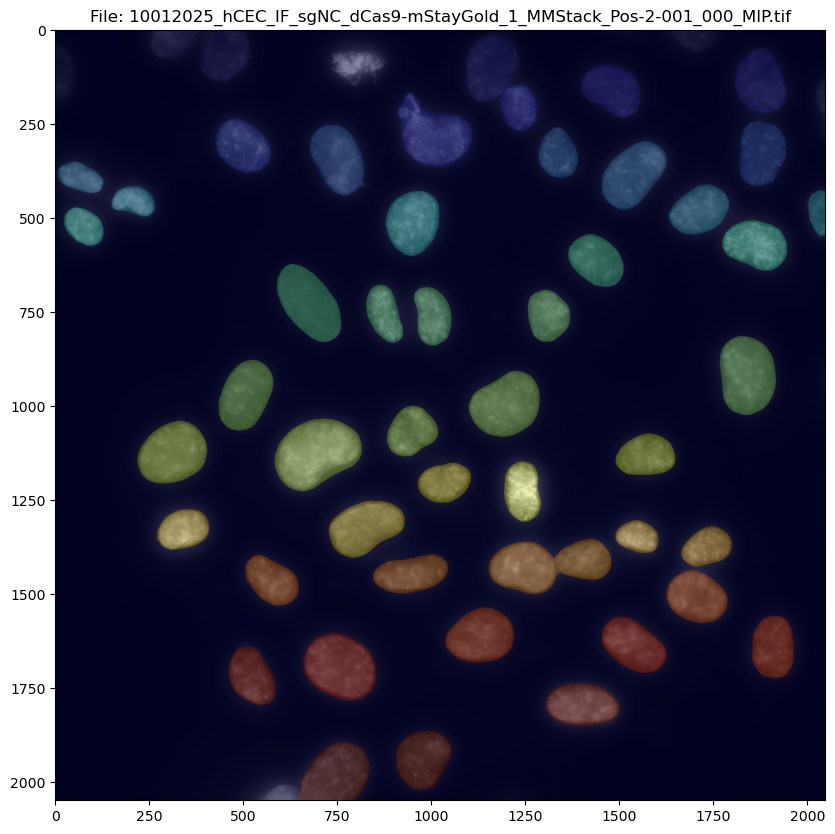

In [8]:
# (Optional) Overlay the corresponding mask on a channel (given as c) of a given image
# to visually inspect

# Specify the index of the image to check
# and the channel to plot — remember C-1 for ImageJ is channel 0 for Python!
e_index = 0
image_index = 89

# Replace with the desired index
c = 0 # remember the channel order in these images

# Access the specific experiment's data
experiment_data = all_experiments_data[experiment_list[e_index]]

# Find the corresponding mask index for the specified image
# and define the image and mask pair
matched_indices = experiment_data["matched_indices"]
mask_index = [pair[1] for pair in matched_indices if pair[0] == image_index][0]

# Define the image and mask pair
my_image = experiment_data['all_images']['image'][image_index]
image_file = experiment_data['file_names']['image'][image_index]
my_mask_n = experiment_data['all_images']['mask_n'][mask_index]

# Select the c channel
channel_image = my_image[c, ...]

# Overlay the mask on the rest of the image if they have the same dimensions
if channel_image.shape != my_mask_n.shape:
    print("Warning: The image and mask sizes do not match. Please check your data.")
else:
    overlay = np.ma.masked_where(my_mask_n == 0, my_mask_n)
    plt.figure(figsize=(10, 10))
    plt.imshow(channel_image, cmap='gray')  # Display the selected channel in grayscale
    plt.imshow(my_mask_n, cmap='jet', alpha=0.25)  # Overlay the mask with transparency
    plt.title(f'File: {image_file}')
    #plt.axis('off')  # Turn off axis labels
    plt.show()

In [9]:
# CHUNK 3 #
# Configure flat-field correction using BaSiCPy

# CSV schema (per experiment we will read parent_directory/<experiment>/experimental-groups.csv)
# Define the column names in experimental-groups.csv files
FILENAME_COL = "filename"   # column with image filenames
GROUP_COL    = "plasmid"      # column with experimental group labels

# Image layout / channels
# Images in memory should be [C, Y, X] or [Y, X] (single-channel).
# If your arrays are [Y, X, C], set this to True and we’ll transpose later.
CHANNELS_LAST = False

# BaSiC estimation options
BASICPY_GET_DARKFIELD   = False   # usually False if you already offset-correct / background-subtract
BASICPY_SAMPLE_FRACTION = 1.0     # use all positions in a group (lower to save RAM/time)
BASICPY_RANDOM_STATE    = 0

# Application options
PRESERVE_MEAN = True
OUT_DTYPE     = None      # None => keep original dtype if integer, else float32
CLIP_OUTPUT   = True
SUFFIX        = "_ffc"    # suffix for corrected files

# ---- Per-experiment helpers (paths & cache) ----
def exp_groups_path(experiment: str) -> Path:
    """parent_directory/<experiment>/experimental-groups.csv"""
    return Path(parent_directory) / experiment / "experimental-groups.csv"

def exp_output_root(experiment: str) -> Path:
    """parent_directory/<experiment>/MIPs_FFC"""
    return Path(parent_directory) / experiment / "MIPs_FFC"

def exp_cache_dir(experiment: str) -> Path:
    """parent_directory/<experiment>/MIPs_FF/_basic_maps"""
    return exp_output_root(experiment) / "_basic_maps"

# Pre-create output + cache dirs for all experiments you plan to process
for exp in experiment_list:
    exp_output_root(exp).mkdir(parents=True, exist_ok=True)
    exp_cache_dir(exp).mkdir(parents=True, exist_ok=True)

# ---- Access to in-memory images ----
# Expectation: all_experiments_data[experiment]["images_by_name"] -> dict[str filename] -> np.ndarray
# If your dict uses a different key, change "images_by_name" below accordingly.
def get_image_from_memory(experiment: str, filename: str):
    """Return the in-memory array for this experiment/filename."""
    return all_experiments_data[experiment]["images_by_name"][filename]

In [10]:
# CHUNK 3.1 #
# Functions to resolve CSV filenames to in-memory items via base_name
# To ensure matching between image names and names listed in experimental-groups.csv

TRACK_KEY = "image"  # we flat-field-correct the image track

def normalize_match_key(base_name: str) -> str:
    """
    Build a robust, comparable key from a base_name:
      - lowercase
      - remove a trailing '_MIP' (case-insensitive) if present
    Example: 'SampleA_MIP' -> 'samplea'
             'SampleA'     -> 'samplea'
    """
    key = base_name.lower()
    key = re.sub(r'_mip$', '', key, flags=re.IGNORECASE)
    return key

def csv_base_from_filename(csv_filename: str) -> str:
    """
    Compute base_name for a CSV entry using YOUR extractor.
    This mirrors how you built all_experiments_data['base_names'].
    """
    return extract_base_name(csv_filename)

def build_memory_base_index(experiment: str, track: str = TRACK_KEY) -> pd.DataFrame:
    """
    Create a lookup table from your in-memory lists:
      base_name (from your loader) --> mem_idx (list index) and mem_filename.
    We also compute a 'match_key' by normalizing base_name (lowercase, strip _MIP).
    If multiple entries share the same match_key, prefer the one whose filename ends with *_MIP.tif/.tiff.
    Returns a DataFrame indexed by 'match_key' with columns: mem_idx, mem_filename, base_name.
    """
    names = all_experiments_data[experiment]["file_names"][track]
    bases = all_experiments_data[experiment]["base_names"][track]
    df = pd.DataFrame({
        "mem_idx": list(range(len(names))),
        "mem_filename": names,
        "base_name": bases,
    })

    # Prefer *_MIP.* when duplicates exist for the same match_key
    prefer_mip = df["mem_filename"].str.lower().str.endswith(("_mip.tif", "_mip.tiff"))
    df = df.assign(match_key=df["base_name"].map(normalize_match_key),
                   prefer_mip=prefer_mip)\
           .sort_values(["match_key", "prefer_mip"], ascending=[True, False])\
           .drop_duplicates(subset="match_key", keep="first")\
           .drop(columns="prefer_mip")

    return df.set_index("match_key")

def csv_add_match_key(df_csv: pd.DataFrame) -> pd.DataFrame:
    """
    Add 'base_name' and 'match_key' columns to the CSV DataFrame (in memory).
    """
    df = df_csv.copy()
    df["base_name"] = df[FILENAME_COL].apply(csv_base_from_filename)
    df["match_key"] = df["base_name"].map(normalize_match_key)
    return df

def get_image_by_index(experiment: str, idx: int, track: str = TRACK_KEY):
    return all_experiments_data[experiment]["all_images"][track][idx]

def get_name_by_index(experiment: str, idx: int, track: str = TRACK_KEY):
    return all_experiments_data[experiment]["file_names"][track][idx]

In [11]:
# CHUNK 4 — BaSiC driver (uses ffc_basicpy module)
# Requires: CHUNK 3 (paths/config), CHUNK 3.1 (base-name merge helpers), and `import ffc_basicpy as ffc`

import os
from pathlib import Path
import numpy as np
import ffc_basicpy as ffc

# -- Cache wrappers that point to your per-experiment cache dir --
def _cache_key(experiment: str, group_name: str, ch: int) -> Path:
    return ffc.cache_key(exp_cache_dir(experiment), group_name, ch)

def _have_cached(experiment: str, group_name: str, ch: int) -> bool:
    return ffc.have_cached(exp_cache_dir(experiment), group_name, ch)

def _save_cache(experiment: str, group_name: str, ch: int, flat: np.ndarray, dark: np.ndarray | None):
    return ffc.save_cache(exp_cache_dir(experiment), group_name, ch, flat, dark)

def _load_cache(experiment: str, group_name: str, ch: int) -> tuple[np.ndarray, np.ndarray | None]:
    return ffc.load_cache(exp_cache_dir(experiment), group_name, ch)

# -- Renamed: estimate maps for one group×channel from in-memory indices --
def estimate_maps_group_channel(
    experiment: str,
    group_df,
    ch: int,
    *,
    idx_col: str = "mem_idx",
):
    """
    Build planes from each position in the group for channel `ch`,
    then estimate flat/dark with BaSiC.
    """
    planes = []
    for idx in group_df[idx_col].astype(int):
        cyx = ffc.to_cyx(get_image_by_index(experiment, idx), channels_last=CHANNELS_LAST)
        if ch >= cyx.shape[0]:
            raise IndexError(
                f"{get_name_by_index(experiment, idx)}: requested channel {ch} "
                f"but image has only {cyx.shape[0]} channels."
            )
        planes.append(cyx[ch])

    flat, dark = ffc.estimate_basic_flat_dark(
        planes,
        get_darkfield=BASICPY_GET_DARKFIELD,
        sample_fraction=BASICPY_SAMPLE_FRACTION,
        random_state=BASICPY_RANDOM_STATE,
    )
    return flat, dark

# -- Renamed: correct one group and save outputs --
def correct_save_group(
    experiment: str,
    group_name: str,
    group_df,
    *,
    idx_col: str = "mem_idx",
):
    """
    Estimate/load maps per channel (shared across the group), apply per position,
    and write to parent_directory/<experiment>/MIPs_FF/<stem>_ffc.tif.
    """
    # Infer channel count from first resolved image
    first_idx = int(group_df[idx_col].iloc[0])
    first_cyx = ffc.to_cyx(get_image_by_index(experiment, first_idx), channels_last=CHANNELS_LAST)
    C, Y, X = first_cyx.shape

    # Estimate or load maps per channel
    flats, darks = [], []
    for c in range(C):
        if _have_cached(experiment, group_name, c):
            flat_c, dark_c = _load_cache(experiment, group_name, c)
        else:
            flat_c, dark_c = estimate_maps_group_channel(experiment, group_df, c, idx_col=idx_col)
            _save_cache(experiment, group_name, c, flat_c, dark_c)
        flats.append(flat_c)
        darks.append(dark_c)

    # Apply & save
    out_dir = exp_output_root(experiment)
    out_dir.mkdir(parents=True, exist_ok=True)

    n_ok = n_err = 0
    for idx in group_df[idx_col].astype(int):
        try:
            cyx = ffc.to_cyx(get_image_by_index(experiment, idx), channels_last=CHANNELS_LAST)
            corrected = ffc.apply_basic_per_channel(
                cyx, flats, darks,
                preserve_mean=PRESERVE_MEAN,
                out_dtype=OUT_DTYPE,
                clip=CLIP_OUTPUT,
            )
            stem = Path(get_name_by_index(experiment, idx)).stem
            out_path = out_dir / f"{stem}{SUFFIX}.tif"
            ffc.write_image_cyx(out_path, corrected)
            n_ok += 1
        except Exception as e:
            print(f"[BaSiC] ERROR writing {get_name_by_index(experiment, idx)}: {e}")
            n_err += 1

    print(f"      ✓ wrote {n_ok} files to {out_dir} ({C} ch, {Y}×{X}); errors: {n_err}")


In [12]:
# CHUNK 5 #
# Run flat-field correction over the experiment_list

def run_basic_ffc():
    for experiment in experiment_list:
        csv_path = exp_groups_path(experiment)
        if not csv_path.exists():
            print(f"[BaSiC] Skipping {experiment}: missing CSV {csv_path}")
            continue

        # 1) Read CSV and compute its base_name/match_key (using your extract_base_name logic)
        df_csv = pd.read_csv(csv_path)
        if FILENAME_COL not in df_csv.columns or GROUP_COL not in df_csv.columns:
            raise ValueError(
                f"{csv_path} must include '{FILENAME_COL}' and '{GROUP_COL}'. "
                f"Found: {list(df_csv.columns)}"
            )
        df_csv = csv_add_match_key(df_csv)  # adds base_name, match_key

        # 2) Build in-memory base_name index once per experiment
        mem_idx_df = build_memory_base_index(experiment).reset_index()  # has: match_key, mem_idx, mem_filename

        # 3) Merge: attach mem_idx to CSV rows via match_key
        merged = df_csv.merge(
            mem_idx_df[["match_key", "mem_idx", "mem_filename"]],
            on="match_key",
            how="left"
        )

        # 4) Report unresolved rows and filter them out
        unresolved = merged[merged["mem_idx"].isna()][FILENAME_COL].tolist()
        if unresolved:
            print(f"[BaSiC] {experiment}: {len(unresolved)} CSV entries couldn't be matched by base_name.")
            for ex in unresolved[:5]:
                print("   unresolved:", ex)

        df_resolved = merged[~merged["mem_idx"].isna()].copy()
        if df_resolved.empty:
            print(f"[BaSiC] {experiment}: no images to process after base_name merge.")
            continue

        df_resolved["mem_idx"] = df_resolved["mem_idx"].astype(int)

        print(f"\n[BaSiC] Experiment: {experiment} | resolved {len(df_resolved)}/{len(merged)} files via base_name")

        # 5) Run per-group correction
        for group_name, group_df in df_resolved.groupby(GROUP_COL, sort=False):
            print(f"  - Group: {group_name} (n={len(group_df)} files)")
            correct_save_group(
                experiment,
                group_name,
                group_df,
                idx_col="mem_idx"
            )

# When ready, run:
run_basic_ffc()


[BaSiC] Experiment: 10012025_hCEC_gH2AX-EdU | resolved 100/100 files via base_name
  - Group: none (n=25 files)
      ✓ wrote 25 files to /Users/nestor/Documents/NYU-ISG/microscope-data/10012025_hCEC_gH2AX-EdU/MIPs_FFC (4 ch, 2048×2048); errors: 0
  - Group: pHAGE_mStayGold_Cen18-ZF1d (n=25 files)
      ✓ wrote 25 files to /Users/nestor/Documents/NYU-ISG/microscope-data/10012025_hCEC_gH2AX-EdU/MIPs_FFC (4 ch, 2048×2048); errors: 0
  - Group: pLenti_sgRNA18-4 (n=25 files)
      ✓ wrote 25 files to /Users/nestor/Documents/NYU-ISG/microscope-data/10012025_hCEC_gH2AX-EdU/MIPs_FFC (4 ch, 2048×2048); errors: 0
  - Group: pLenti_sgNC (n=25 files)
      ✓ wrote 25 files to /Users/nestor/Documents/NYU-ISG/microscope-data/10012025_hCEC_gH2AX-EdU/MIPs_FFC (4 ch, 2048×2048); errors: 0

[BaSiC] Experiment: 10062025_hCEC_gH2AX-EdU | resolved 150/150 files via base_name
  - Group: none (n=25 files)
      ✓ wrote 25 files to /Users/nestor/Documents/NYU-ISG/microscope-data/10062025_hCEC_gH2AX-EdU/MIPs

At this point, if all went well, FFC has been done for all image groups and the corrected files have been written to disk under MIPs_FFC. Below are a few cells that will let us visually inspect the results of the correction.

In [13]:
# Inspect the learned flat/dark maps

def load_maps(experiment, group_name, ch):
    path = _cache_key(experiment, group_name, ch)  # from CHUNK 5
    d = np.load(path)
    flat = d["flat"].astype(np.float32)
    dark = None if d["dark"].size == 0 else d["dark"].astype(np.float32)
    return flat, dark

def show_flat_map(flat):
    plt.figure()
    plt.imshow(flat)         # [Y, X]
    plt.title(f"Flat map (min={flat.min():.3g}, med={np.median(flat):.3g}, max={flat.max():.3g})")
    plt.colorbar()
    plt.show()

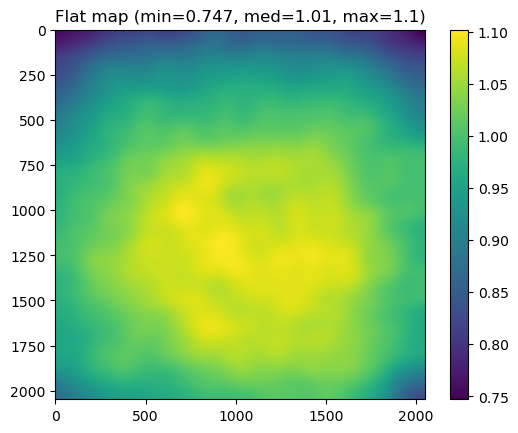

Darkfield is absent


In [14]:
# Plot the learned flat/dark maps
# Define the test_group to plot -- the name of the plasmid or experimental group you'd like to look at

test_group = "pLenti_sgRNA18-4"

flat, dark = load_maps(experiment_list[0], test_group, ch=0)
show_flat_map(flat)
print("Darkfield is", "present" if dark is not None else "absent")

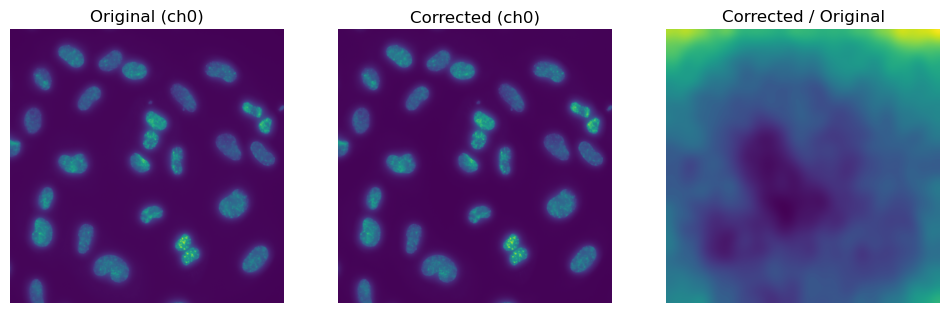

In [16]:
# Compare a single image before vs after FFC

def quick_compare(experiment, idx):
    stem = Path(get_name_by_index(experiment, idx)).stem  # e.g., sample_MIP
    out_path = exp_output_root(experiment) / f"{stem}{SUFFIX}.tif"
    orig = np.asarray(get_image_by_index(experiment, idx))      # [C, Y, X] (via CHUNK 3.1b)
    corr = imread(str(out_path))                                # saved as [C, Y, X] (our writer)
    if corr.ndim == 2:
        corr = corr[np.newaxis, ...]
    # show first channel
    c = 0
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(orig[c]); axs[0].set_title("Original (ch0)")
    axs[1].imshow(corr[c]); axs[1].set_title("Corrected (ch0)")
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = corr[c] / (orig[c].astype(np.float32) + 1e-6)
    axs[2].imshow(ratio); axs[2].set_title("Corrected / Original")
    for ax in axs: ax.axis('off')
    plt.show()

# Example
# Indicate the experiment and image to show -- experiment using the index in experiment_list
# and image by index
quick_compare(experiment_list[1], 15)

In [18]:
# REPORT: write an FFC run summary per experiment within MIPs_FFC

from datetime import datetime
import os, glob, json

def _fmt(v):
    if isinstance(v, (list, tuple)):
        return json.dumps(list(v))
    return str(v)

def write_ffc_reports():
    # versions (best effort)
    def _vers(pkg):
        try:
            import importlib.metadata as im
            return im.version(pkg)
        except Exception:
            return "unknown"

    versions = {
        "basicpy": _vers("basicpy"),
        "jax": _vers("jax"),
        "jaxlib": _vers("jaxlib"),
        "numpy": _vers("numpy"),
        "hyperactive": _vers("hyperactive"),
    }

    env_bits = {
        "JAX_PLATFORMS": os.environ.get("JAX_PLATFORMS", ""),
        "BASIC_LOG_LEVEL": os.environ.get("BASIC_LOG_LEVEL", ""),
    }

    cfg = {
        "FILENAME_COL": FILENAME_COL,
        "GROUP_COL": GROUP_COL,
        "CHANNELS_LAST": CHANNELS_LAST,
        "BASICPY_GET_DARKFIELD": BASICPY_GET_DARKFIELD,
        "BASICPY_SAMPLE_FRACTION": BASICPY_SAMPLE_FRACTION,
        "BASICPY_RANDOM_STATE": BASICPY_RANDOM_STATE,
        "PRESERVE_MEAN": PRESERVE_MEAN,
        "OUT_DTYPE": None if OUT_DTYPE is None else str(OUT_DTYPE),
        "CLIP_OUTPUT": CLIP_OUTPUT,
        "SUFFIX": SUFFIX,
        "OUTPUT_SUBDIR": "MIPs_FF",
        "CacheDir": "_basic_maps",
        "Matching": "CSV filename → base_name (extract_base_name) → match_key (lowercase; strip trailing _MIP)",
    }

    now = datetime.now()
    ts = now.strftime("%Y-%m-%d %H:%M:%S")   # keep full timestamp inside the report
    date_tag = now.strftime("%Y%m%d")        # date-only for filename
    any_written = False

    for experiment in experiment_list:
        out_dir = exp_output_root(experiment)
        corrected = sorted(glob.glob(str(out_dir / f"*{SUFFIX}.tif")))
        if not corrected:
            continue

        lines = []
        lines.append("Flat-Field Correction (BaSiCPy) — Run Summary")
        lines.append("=" * 60)
        lines.append(f"Experiment: {experiment}")
        lines.append(f"Run time:  {ts}")
        lines.append("")
        lines.append("Paths")
        lines.append(f"  parent_directory: {parent_directory}")
        lines.append(f"  output_dir:       {out_dir}")
        lines.append(f"  csv_path:         {exp_groups_path(experiment)}")
        lines.append("")
        lines.append("Package versions")
        for k, v in versions.items():
            lines.append(f"  {k}: {v}")
        if any(env_bits.values()):
            lines.append("")
            lines.append("Environment hints")
            for k, v in env_bits.items():
                if v:
                    lines.append(f"  {k}={v}")

        lines.append("")
        lines.append("Configuration")
        for k, v in cfg.items():
            lines.append(f"  {k}: {_fmt(v)}")

        lines.append("")
        lines.append("Outputs")
        lines.append(f"  corrected_files_written: {len(corrected)}")
        preview = corrected[:5]
        for p in preview:
            lines.append(f"    - {Path(p).name}")
        if len(corrected) > len(preview):
            lines.append(f"    ... (+{len(corrected)-len(preview)} more)")

        report_text = "\n".join(lines)

        # filename: date-only, leading underscore; de-duplicate if already exists
        base_name = f"_ffc_run_{date_tag}.txt"
        report_path = out_dir / base_name
        n = 2
        while report_path.exists():
            report_path = out_dir / f"_ffc_run_{date_tag}-{n}.txt"
            n += 1

        with open(report_path, "w", encoding="utf-8") as f:
            f.write(report_text)

        print(f"[FFC] Wrote report: {report_path}")
        any_written = True

    if not any_written:
        print("[FFC] No corrected files found in any experiment; no reports written.")

# Run after your plots/QC:
write_ffc_reports()


[FFC] Wrote report: /Users/nestor/Documents/NYU-ISG/microscope-data/10012025_hCEC_gH2AX-EdU/MIPs_FFC/_ffc_run_20251017.txt
[FFC] Wrote report: /Users/nestor/Documents/NYU-ISG/microscope-data/10062025_hCEC_gH2AX-EdU/MIPs_FFC/_ffc_run_20251017.txt
